# Employee Turnover Analytics

## Course-End Project

### Problem Statement
Portobello Tech wants to predict employee turnover and understand the main drivers behind attrition. The HR team has shared historical employee data containing satisfaction, evaluation, workload, tenure, accidents, promotions, department, and salary information.

### Project Objectives
- Perform data quality checks.
- Identify the factors contributing most to employee turnover through EDA.
- Cluster employees who left based on satisfaction and evaluation.
- Handle class imbalance using SMOTE.
- Train and compare Logistic Regression, Random Forest, and Gradient Boosting using 5-fold cross-validation.
- Select the best model using appropriate evaluation metrics.
- Predict turnover probability and recommend retention strategies by risk zone.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = Path("1751024723_hr_comma_sep") / "HR_comma_sep.csv"
RANDOM_STATE = 123

## 1. Load the Dataset

The original dataset uses the column name `sales` to represent department. For readability, it is renamed to `department`.

In [2]:
df = pd.read_csv(DATA_PATH).rename(columns={"sales": "department"})
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 2. Data Quality Checks

The assignment explicitly asks for missing-value analysis. I also checked duplicate rows because duplicates can overweight repeated employee profiles during model training.

In [3]:
quality_check = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique()
})
display(quality_check)

print("Duplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
display(df["left"].value_counts().rename_axis("left").to_frame("count"))
display((df["left"].value_counts(normalize=True) * 100).round(2).rename_axis("left").to_frame("percentage"))

,dtype,missing_values,missing_pct,nunique
satisfaction_level,float64,0,0.0,92
last_evaluation,float64,0,0.0,65
number_project,int64,0,0.0,6
average_montly_hours,int64,0,0.0,215
time_spend_company,int64,0,0.0,8
Work_accident,int64,0,0.0,2
left,int64,0,0.0,2
promotion_last_5years,int64,0,0.0,2
department,object,0,0.0,10
salary,object,0,0.0,3


Duplicate rows: 3008

Target distribution:


,count
left,
0,11428
1,3571


,percentage
left,
0,76.19
1,23.81


**Inference:** The dataset contains no missing values. Duplicate rows are present, so I remove them before modeling to avoid giving repeated observations extra weight. The target is imbalanced, with employees who stayed forming the majority class.

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (11991, 10)


## 3. Exploratory Data Analysis

This section addresses the required EDA tasks and builds additional context around employee turnover.

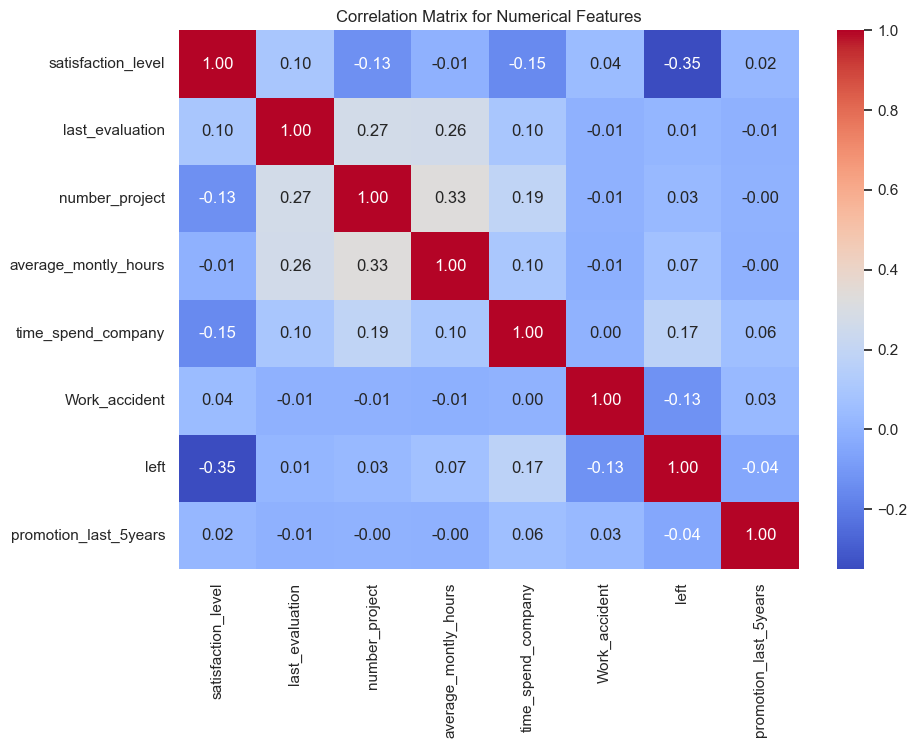

,correlation_with_left
left,1.000000
time_spend_company,0.173295
average_montly_hours,0.070409
number_project,0.030928
last_evaluation,0.013520
promotion_last_5years,-0.044657
Work_accident,-0.125436
satisfaction_level,-0.350558


In [5]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Numerical Features")
plt.show()

corr_with_target = corr["left"].sort_values(ascending=False).to_frame("correlation_with_left")
display(corr_with_target)

**Inference:** Employee turnover is most strongly associated with low `satisfaction_level`, higher `time_spend_company`, and the absence of `Work_accident`. Correlation alone does not prove causation, but it helps identify the strongest signals for further analysis.

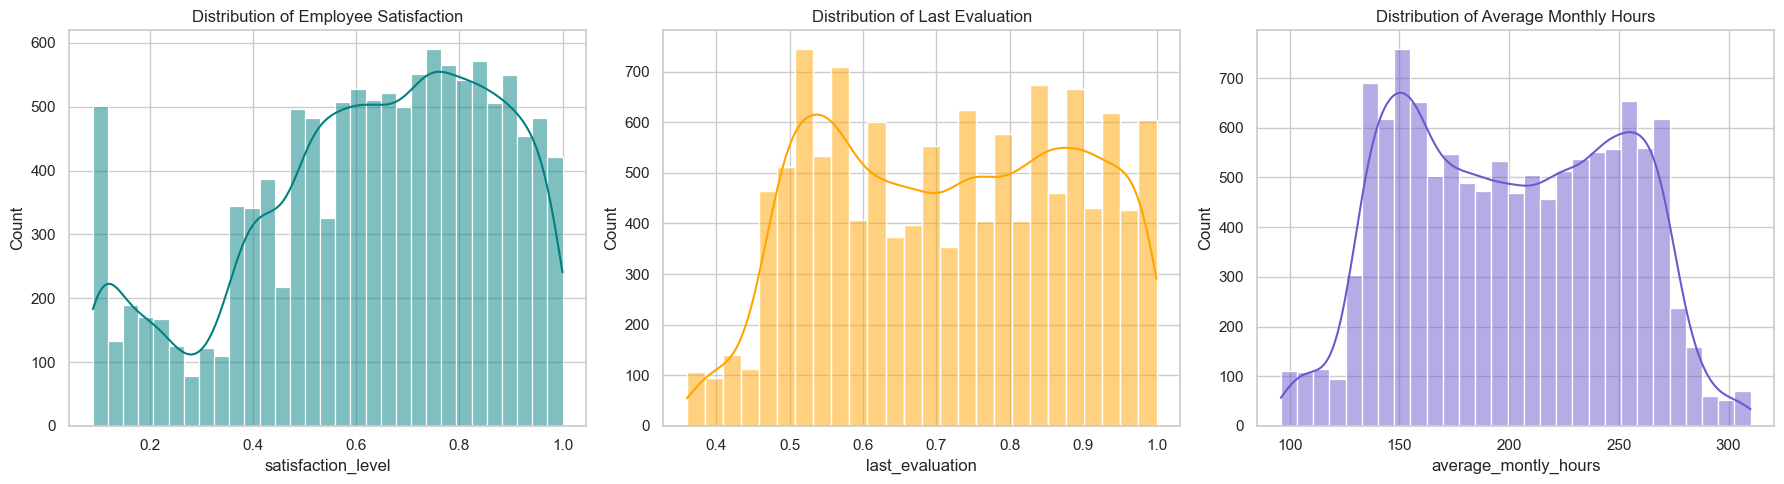

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["satisfaction_level"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Employee Satisfaction")

sns.histplot(df["last_evaluation"], kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Last Evaluation")

sns.histplot(df["average_montly_hours"], kde=True, ax=axes[2], color="slateblue")
axes[2].set_title("Distribution of Average Monthly Hours")

plt.tight_layout()
plt.show()

**Inference:** Satisfaction is spread across the full range with visible concentration in the lower and higher bands. Evaluation scores cluster around mid-to-high values, and monthly hours show wide workload variation, suggesting that some employees are consistently working much longer hours than others.

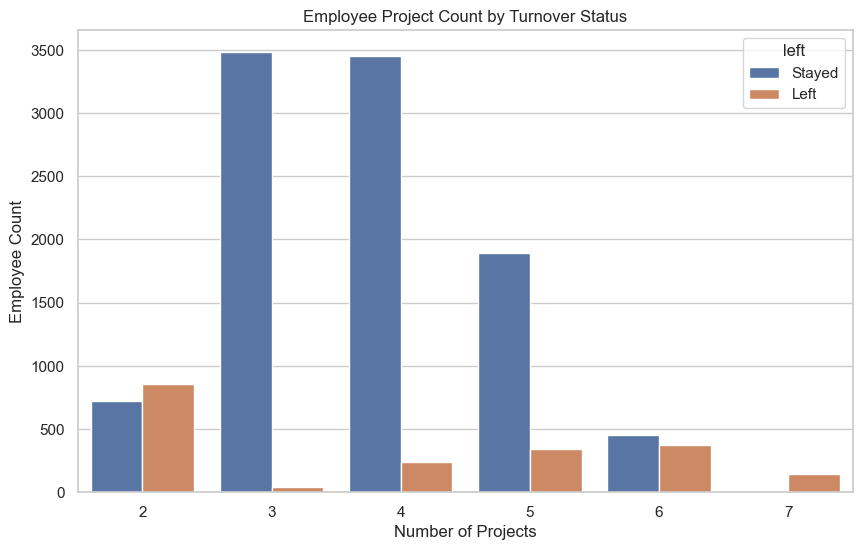

left,0,1
number_project,,
2,45.83,54.17
3,98.92,1.08
4,93.57,6.43
5,84.64,15.36
6,55.08,44.92
7,0.00,100.00


In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="number_project", hue="left")
plt.title("Employee Project Count by Turnover Status")
plt.xlabel("Number of Projects")
plt.ylabel("Employee Count")
plt.legend(title="left", labels=["Stayed", "Left"])
plt.show()

project_turnover = (
    pd.crosstab(df["number_project"], df["left"], normalize="index") * 100
).round(2)
display(project_turnover)

**Inference:** Employees with 3 to 4 projects are much more likely to stay, while those with 2 projects or very high project loads such as 6 to 7 projects show much higher turnover. This suggests both under-utilization and overload can contribute to attrition.

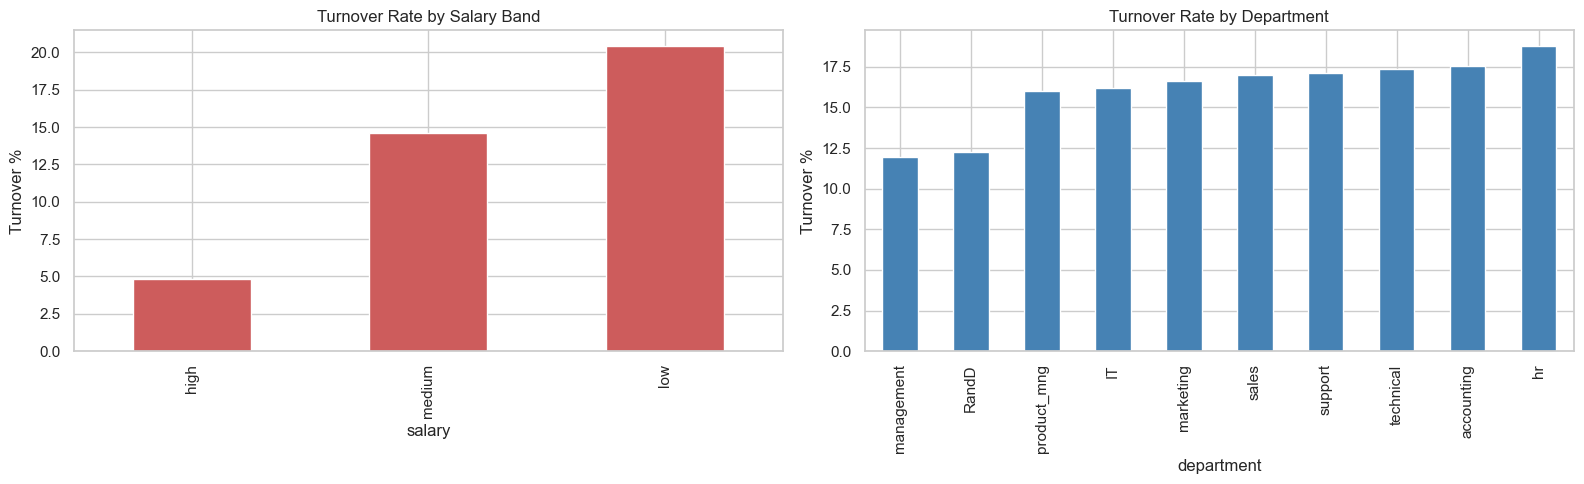

left,0,1
salary,,
high,95.15,4.85
low,79.55,20.45
medium,85.38,14.62


left,0,1
department,,
IT,83.81,16.19
RandD,87.75,12.25
accounting,82.45,17.55
hr,81.20,18.80
management,88.07,11.93
marketing,83.36,16.64
product_mng,83.97,16.03
sales,83.02,16.98
support,82.87,17.13


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

salary_turnover = pd.crosstab(df["salary"], df["left"], normalize="index") * 100
salary_turnover[1].sort_values().plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set_title("Turnover Rate by Salary Band")
axes[0].set_ylabel("Turnover %")

dept_turnover = pd.crosstab(df["department"], df["left"], normalize="index") * 100
dept_turnover[1].sort_values().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Turnover Rate by Department")
axes[1].set_ylabel("Turnover %")

plt.tight_layout()
plt.show()

display(salary_turnover.round(2))
display(dept_turnover.round(2))

**Inference:** Low-salary employees leave at a much higher rate than high-salary employees. Department differences exist, but salary, satisfaction, workload, and tenure appear to be stronger turnover drivers than department alone.

## 4. K-Means Clustering of Employees Who Left

The clustering step is performed only on employees who left the company and only on the required columns: `satisfaction_level`, `last_evaluation`, and `left`.

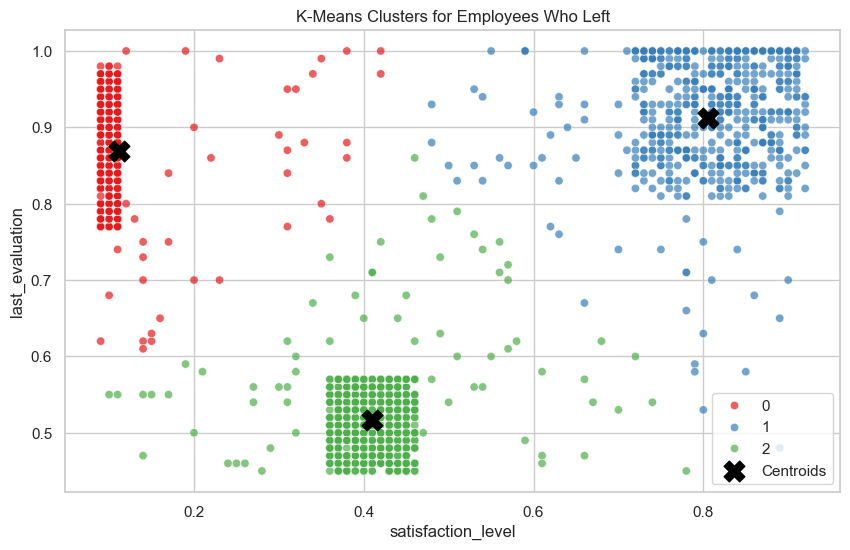

,satisfaction_level,last_evaluation
cluster,,
0,0.111,0.869
1,0.806,0.913
2,0.410,0.517


,employee_count
cluster,
0,534
1,555
2,902


In [9]:
left_employees = df[df["left"] == 1][["satisfaction_level", "last_evaluation", "left"]].copy()

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
left_employees["cluster"] = kmeans.fit_predict(left_employees[["satisfaction_level", "last_evaluation"]])

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["satisfaction_level", "last_evaluation"]
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=left_employees,
    x="satisfaction_level",
    y="last_evaluation",
    hue="cluster",
    palette="Set1",
    alpha=0.7
)
plt.scatter(
    centroids["satisfaction_level"],
    centroids["last_evaluation"],
    c="black",
    s=220,
    marker="X",
    label="Centroids"
)
plt.title("K-Means Clusters for Employees Who Left")
plt.legend()
plt.show()

cluster_summary = left_employees.groupby("cluster")[["satisfaction_level", "last_evaluation"]].mean().round(3)
cluster_sizes = left_employees["cluster"].value_counts().sort_index().to_frame("employee_count")

display(cluster_summary)
display(cluster_sizes)

**Cluster Interpretation:**
- One cluster typically represents highly dissatisfied employees with relatively strong evaluations. These employees may be productive but unhappy.
- One cluster captures employees with moderate satisfaction and moderate evaluation, which can indicate disengagement or a weaker fit.
- One cluster contains employees with high evaluation but still high turnover, suggesting that even high performers may leave if workload, growth, or rewards are not aligned.

## 5. Preprocessing and Class Imbalance Handling

The categorical columns are converted to numerical columns using `get_dummies()`, then the data is split using stratification with an 80:20 train-test ratio and `random_state=123`. SMOTE is applied only to the training data.

In [10]:
X = pd.get_dummies(df.drop(columns=["left"]), drop_first=True)
y = df["left"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("X shape after encoding:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nClass distribution before SMOTE:")
print(y_train.value_counts())
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

X shape after encoding: (11991, 18)
Train shape: (9592, 18)
Test shape: (2399, 18)

Class distribution before SMOTE:
left
0    7999
1    1593
Name: count, dtype: int64

Class distribution after SMOTE:
left
0    7999
1    7999
Name: count, dtype: int64


## 6. Model Training with 5-Fold Cross-Validation

To avoid data leakage, SMOTE is included inside an `imblearn` pipeline during cross-validation. This keeps oversampling restricted to each training fold.


Logistic Regression - Cross-Validated Classification Report


,precision,recall,f1-score,support
0,0.9249,0.8281,0.8738,7999.0000
1,0.4342,0.6623,0.5245,1593.0000
accuracy,0.8006,0.8006,0.8006,0.8006
macro avg,0.6795,0.7452,0.6992,9592.0000
weighted avg,0.8434,0.8006,0.8158,9592.0000


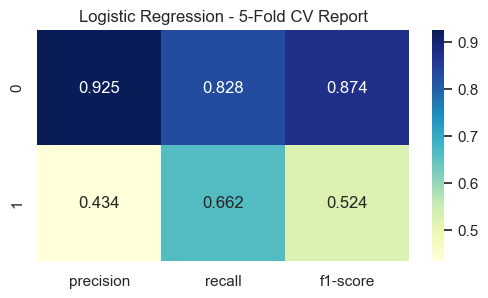

Logistic Regression - Test Classification Report


,precision,recall,f1-score,support
0,0.9252,0.8221,0.8706,2001.0000
1,0.4267,0.6658,0.5201,398.0000
accuracy,0.7962,0.7962,0.7962,0.7962
macro avg,0.6760,0.7440,0.6954,2399.0000
weighted avg,0.8425,0.7962,0.8125,2399.0000


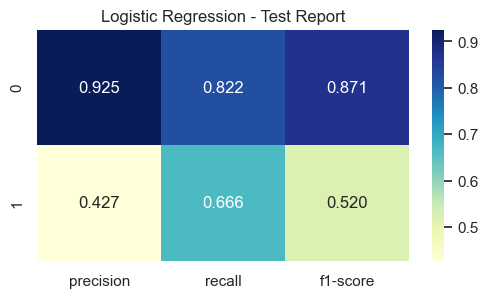


Random Forest - Cross-Validated Classification Report


,precision,recall,f1-score,support
0,0.9827,0.9937,0.9882,7999.0000
1,0.9667,0.9121,0.9386,1593.0000
accuracy,0.9802,0.9802,0.9802,0.9802
macro avg,0.9747,0.9529,0.9634,9592.0000
weighted avg,0.9800,0.9802,0.9800,9592.0000


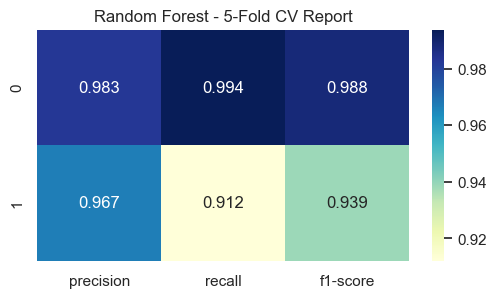

Random Forest - Test Classification Report


,precision,recall,f1-score,support
0,0.9812,0.9900,0.9856,2001.0000
1,0.9474,0.9045,0.9254,398.0000
accuracy,0.9758,0.9758,0.9758,0.9758
macro avg,0.9643,0.9473,0.9555,2399.0000
weighted avg,0.9756,0.9758,0.9756,2399.0000


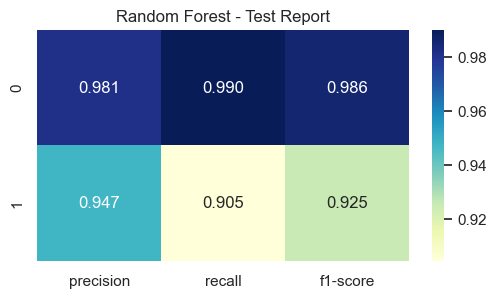


Gradient Boosting - Cross-Validated Classification Report


,precision,recall,f1-score,support
0,0.9862,0.9794,0.9828,7999.0000
1,0.8999,0.9309,0.9151,1593.0000
accuracy,0.9713,0.9713,0.9713,0.9713
macro avg,0.9430,0.9552,0.9490,9592.0000
weighted avg,0.9718,0.9713,0.9715,9592.0000


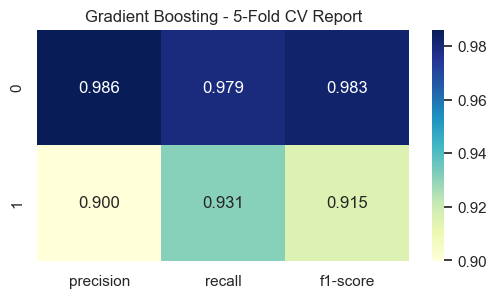

Gradient Boosting - Test Classification Report


,precision,recall,f1-score,support
0,0.9843,0.9710,0.9776,2001.0000
1,0.8635,0.9221,0.8919,398.0000
accuracy,0.9629,0.9629,0.9629,0.9629
macro avg,0.9239,0.9466,0.9347,2399.0000
weighted avg,0.9643,0.9629,0.9634,2399.0000


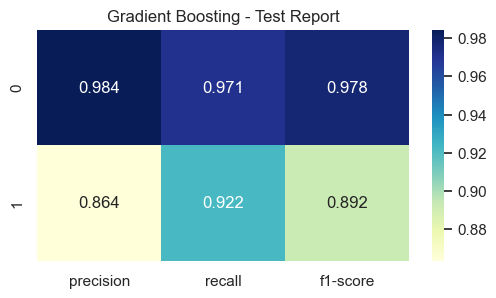

,Model,CV ROC-AUC,Test ROC-AUC,Test Precision (Left=1),Test Recall (Left=1),Test F1 (Left=1)
0,Gradient Boosting,0.9850,0.9790,0.8635,0.9221,0.8919
1,Random Forest,0.9817,0.9766,0.9474,0.9045,0.9254
2,Logistic Regression,0.8096,0.8034,0.4267,0.6658,0.5201


In [11]:
def plot_classification_report(y_true, y_pred, title):
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    display(report_df.round(4))

    heatmap_df = report_df.loc[["0", "1"], ["precision", "recall", "f1-score"]]
    plt.figure(figsize=(6, 3))
    sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt=".3f")
    plt.title(title)
    plt.show()


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = {}
summary_rows = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model),
    ])

    cv_predictions = cross_val_predict(
        pipeline, X_train, y_train, cv=cv, method="predict"
    )
    cv_probabilities = cross_val_predict(
        pipeline, X_train, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    pipeline.fit(X_train, y_train)
    test_predictions = pipeline.predict(X_test)
    test_probabilities = pipeline.predict_proba(X_test)[:, 1]

    results[model_name] = {
        "pipeline": pipeline,
        "cv_predictions": cv_predictions,
        "cv_probabilities": cv_probabilities,
        "test_predictions": test_predictions,
        "test_probabilities": test_probabilities,
        "cv_auc": roc_auc_score(y_train, cv_probabilities),
        "test_auc": roc_auc_score(y_test, test_probabilities),
        "confusion_matrix": confusion_matrix(y_test, test_predictions),
    }

    summary_rows.append({
        "Model": model_name,
        "CV ROC-AUC": results[model_name]["cv_auc"],
        "Test ROC-AUC": results[model_name]["test_auc"],
        "Test Precision (Left=1)": classification_report(
            y_test, test_predictions, output_dict=True
        )["1"]["precision"],
        "Test Recall (Left=1)": classification_report(
            y_test, test_predictions, output_dict=True
        )["1"]["recall"],
        "Test F1 (Left=1)": classification_report(
            y_test, test_predictions, output_dict=True
        )["1"]["f1-score"],
    })

    print(f"\n{model_name} - Cross-Validated Classification Report")
    plot_classification_report(y_train, cv_predictions, f"{model_name} - 5-Fold CV Report")

    print(f"{model_name} - Test Classification Report")
    plot_classification_report(y_test, test_predictions, f"{model_name} - Test Report")


summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["Test ROC-AUC", "Test Recall (Left=1)", "Test F1 (Left=1)"],
    ascending=False
).reset_index(drop=True)

display(summary_df.round(4))

## 7. Best Model Selection and Metric Justification

ROC-AUC is useful for comparing the overall ranking quality of the models, while recall is especially important for the `left=1` class because missing an employee who is likely to leave is more costly than incorrectly flagging an employee for retention outreach.

In HR attrition prediction:
- **Recall** matters because false negatives mean the company fails to identify employees who are actually at risk.
- **Precision** still matters because low precision would waste retention effort on too many employees who were not likely to leave.
- **ROC-AUC** helps compare discrimination power across models, independent of a single threshold.

The notebook selects the best model programmatically from the evaluation summary.

Best model selected: Gradient Boosting


,importance
satisfaction_level,0.439801
time_spend_company,0.343236
last_evaluation,0.079812
average_montly_hours,0.073063
number_project,0.036889
Work_accident,0.009895
salary_medium,0.006908
salary_low,0.004331
department_technical,0.001584
department_support,0.001579


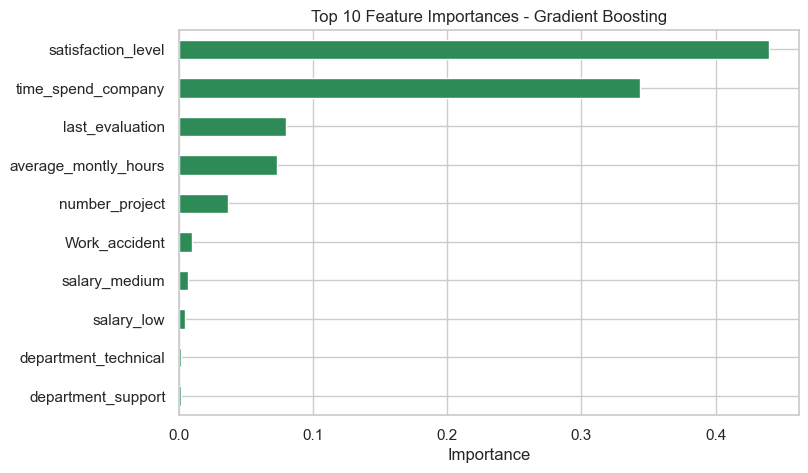

In [12]:
best_model_name = summary_df.loc[0, "Model"]
best_model = results[best_model_name]["pipeline"]

print("Best model selected:", best_model_name)

if best_model_name in ["Random Forest", "Gradient Boosting"]:
    feature_importance = pd.Series(
        best_model.named_steps["model"].feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    display(feature_importance.head(10).to_frame("importance"))

    plt.figure(figsize=(8, 5))
    feature_importance.head(10).sort_values().plot(kind="barh", color="seagreen")
    plt.title(f"Top 10 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.show()
else:
    coefficients = pd.Series(
        best_model.named_steps["model"].coef_[0],
        index=X.columns
    ).sort_values(key=np.abs, ascending=False)
    display(coefficients.head(10).to_frame("coefficient"))

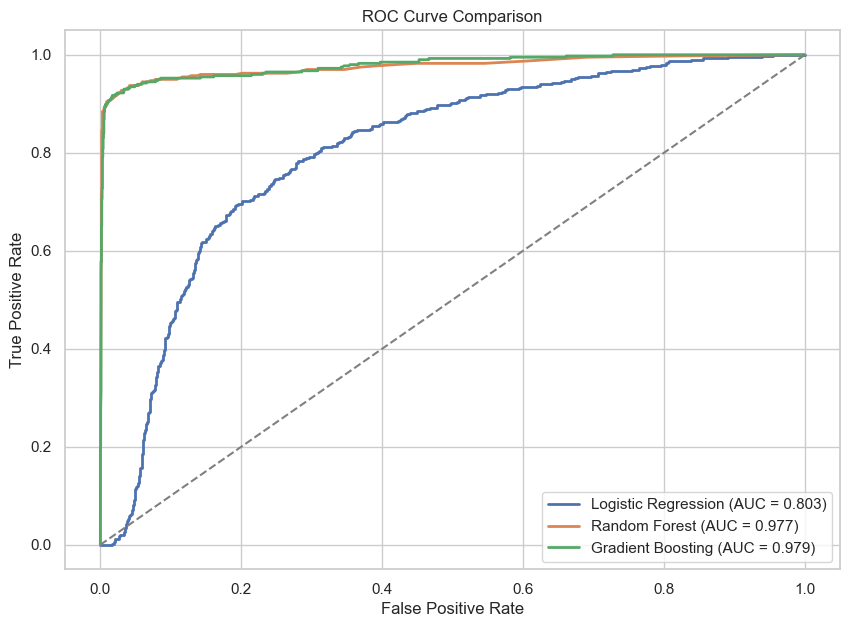

In [13]:
plt.figure(figsize=(10, 7))

for model_name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result["test_probabilities"])
    auc_score = roc_auc_score(y_test, result["test_probabilities"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

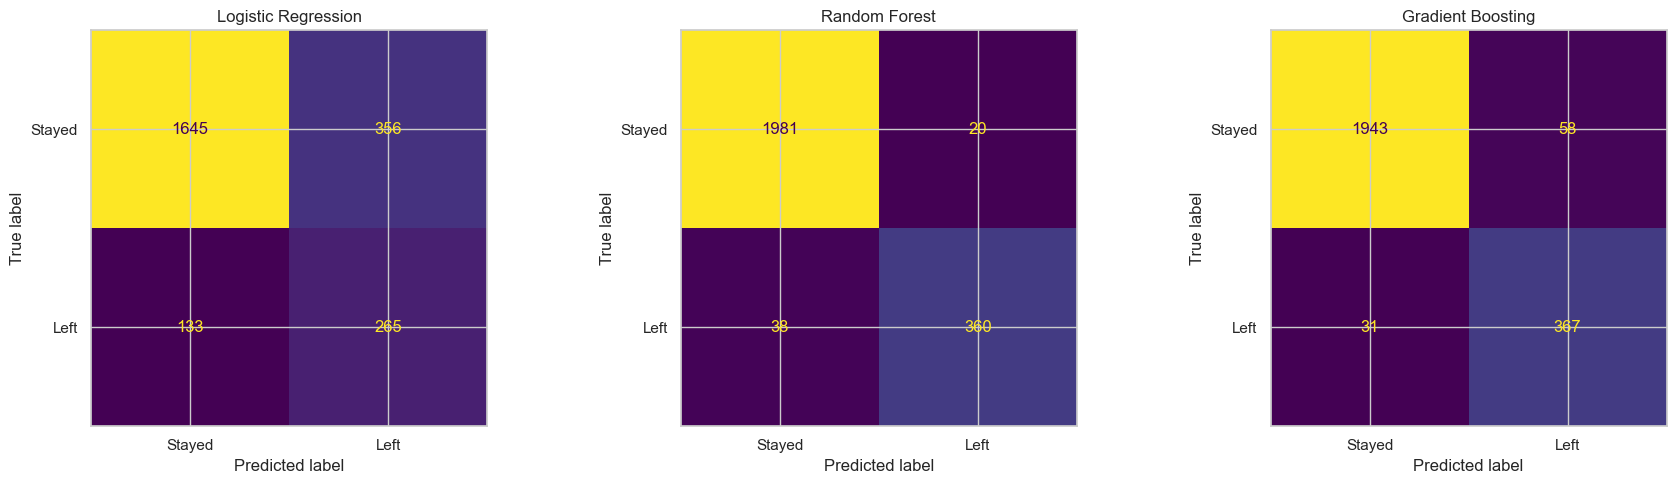

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, result) in zip(axes, results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=["Stayed", "Left"]
    ).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

**Confusion Matrix Interpretation:** Between recall and precision, recall is the more important metric for this use case because HR wants to capture as many at-risk employees as possible. A false negative means an employee who was likely to leave was never targeted with an intervention. Precision remains important as a secondary metric to keep retention programs focused and cost-effective.

## 8. Retention Strategy by Risk Zone

Using the best model, turnover probabilities are predicted on the test set and employees are grouped into the required risk zones.

,employee_count,avg_probability,actual_turnover_rate
risk_zone,,,
Safe Zone (Green),1840,4.29,1.03
Low-Risk Zone (Yellow),155,33.86,9.03
Medium-Risk Zone (Orange),68,77.64,54.41
High-Risk Zone (Red),336,96.67,97.62


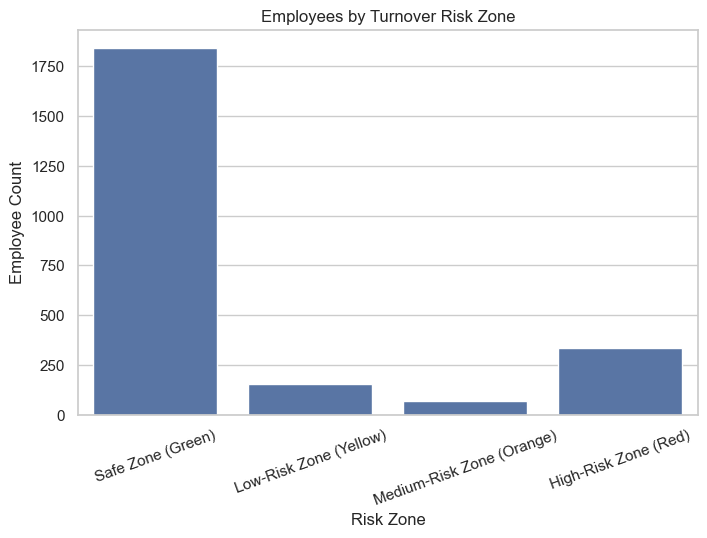

In [15]:
turnover_scores = pd.DataFrame({
    "actual_left": y_test.reset_index(drop=True),
    "turnover_probability": results[best_model_name]["test_probabilities"]
})

turnover_scores["risk_zone"] = pd.cut(
    turnover_scores["turnover_probability"],
    bins=[-np.inf, 0.20, 0.60, 0.90, np.inf],
    labels=[
        "Safe Zone (Green)",
        "Low-Risk Zone (Yellow)",
        "Medium-Risk Zone (Orange)",
        "High-Risk Zone (Red)"
    ]
)

zone_summary = turnover_scores.groupby("risk_zone", observed=False).agg(
    employee_count=("risk_zone", "size"),
    avg_probability=("turnover_probability", "mean"),
    actual_turnover_rate=("actual_left", "mean")
)

zone_summary["avg_probability"] = (zone_summary["avg_probability"] * 100).round(2)
zone_summary["actual_turnover_rate"] = (zone_summary["actual_turnover_rate"] * 100).round(2)

display(zone_summary)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=turnover_scores,
    x="risk_zone",
    order=[
        "Safe Zone (Green)",
        "Low-Risk Zone (Yellow)",
        "Medium-Risk Zone (Orange)",
        "High-Risk Zone (Red)"
    ]
)
plt.title("Employees by Turnover Risk Zone")
plt.xlabel("Risk Zone")
plt.ylabel("Employee Count")
plt.xticks(rotation=20)
plt.show()

## Recommended Retention Actions

| Risk Zone | Suggested Action |
|---|---|
| Safe Zone (Green) | Maintain engagement through regular recognition, manager check-ins, and career visibility. |
| Low-Risk Zone (Yellow) | Monitor workload, discuss career progression, and watch for early signs of dissatisfaction. |
| Medium-Risk Zone (Orange) | Schedule targeted manager/HR intervention, review salary fairness, and rebalance workload or projects. |
| High-Risk Zone (Red) | Immediate retention action: one-on-one conversation, compensation review, role redesign, internal mobility options, and an action plan with leadership visibility. |

**Targeted Insight:** Based on the EDA and model results, the highest-risk employees are typically those with low satisfaction, long tenure, extreme workloads, and limited promotion growth. These employees should be prioritized for retention programs.

## 9. Conclusion

This project shows that employee attrition can be predicted effectively using historical HR data. Satisfaction level, tenure, workload, project count, and salary-related effects are key attrition drivers. After handling class imbalance with SMOTE and comparing three supervised learning models, the best model can be used to assign turnover probabilities and support practical retention decisions.